<a href="https://colab.research.google.com/github/Shivam-7394/Object-Detection/blob/main/Object_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **`See The World Through AI`**

# **Day 1: Setup & Image Detection**
Goal: Set up YOLO and detect objects in a single image.
- Install and import YOLO (Ultralytics YOLOv8)
- Load pretrained model
- Run inference on an image
- Display results

YOLO - you only look once

In [ ]:
!pip install -q ultralytics opencv-python-headless matplotlib pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.5 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt
from PIL import Image
from google.colab import files

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
print("Uploaded:", file_name)

Saving Golden-Retriever.webp to Golden-Retriever.webp
Uploaded: Golden-Retriever.webp


In [ ]:
model=YOLO('yolov8n.pt')

In [ ]:
results = model(file_name)
annotated = results[0].plot()


image 1/1 /content/Golden-Retriever.webp: 640x640 1 dog, 7.8ms
Speed: 2.8ms preprocess, 7.8ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


In [ ]:
plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(annotated,cv2.COLOR_BGR2RGB))
plt.axis('off')

NameError: name 'annotated' is not defined

<Figure size 1200x800 with 0 Axes>

# **Day 2: Object Detection on Video**
Goal: Use YOLO to detect objects in video frames.
- Load and process video file frame-by-frame
- Save output video with bounding boxes

In [ ]:
uploaded=files.upload()
video_path=list(uploaded.keys())[0]
print("Uploaded:",video_path)

Saving Video on a street from an old time #shorts#videos#treding#street#viral.mp4 to Video on a street from an old time #shorts#videos#treding#street#viral.mp4
Uploaded: Video on a street from an old time #shorts#videos#treding#street#viral.mp4


In [ ]:
output_path="output_detected.mp4"
cap=cv2.VideoCapture(video_path)
width=int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height=int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps=cap.get(cv2.CAP_PROP_FPS)or 25.0
fourcc=cv2.VideoWriter_fourcc(*'mp4v')
out=cv2.VideoWriter(output_path,fourcc,fps,(width,height))

frame_count=0
while True:
  ret, frame= cap.read()
  if not ret:
    break
  results=model(frame)
  annotated=results[0].plot()
  out.write(annotated)
  frame_count+=1
  if frame_count%50==0:
    print(f"Processed {frame_count} frames")
cap.release()
out.release()

print("Video Saved:",output_path)
files.download(output_path)


0: 640x384 5 persons, 1 car, 148.7ms
Speed: 24.8ms preprocess, 148.7ms inference, 687.4ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 5 persons, 1 car, 23.9ms
Speed: 3.4ms preprocess, 23.9ms inference, 9.4ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 5 persons, 1 car, 11.0ms
Speed: 2.3ms preprocess, 11.0ms inference, 6.0ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 5 persons, 1 car, 13.5ms
Speed: 2.4ms preprocess, 13.5ms inference, 7.4ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 9 persons, 1 car, 1 umbrella, 11.4ms
Speed: 2.3ms preprocess, 11.4ms inference, 8.1ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 7 persons, 1 car, 1 umbrella, 10.9ms
Speed: 2.4ms preprocess, 10.9ms inference, 7.4ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 6 persons, 1 car, 1 umbrella, 10.6ms
Speed: 2.1ms preprocess, 10.6ms inference, 24.9ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 8 person

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Day 3: Live Webcam Detection**
Goal: Detect objects from webcam feed in real time.
- Use OpenCV's webcam capture
- Display detection in real-time window

In [ ]:

!pip install -q ultralytics opencv-python-headless pillow
from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt
from base64 import b64decode
from google.colab import output

model = YOLO('yolov8n.pt')


def take_photo(filename='snapshot.jpg'):
    js = """
    async function takePhoto() {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);
      document.body.appendChild(div);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize window
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture button
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getTracks().forEach(track => track.stop());
      const imgData = canvas.toDataURL('image/jpeg').split(',')[1];
      div.remove();
      return imgData;
    }
    takePhoto();
    """
    data = output.eval_js(js)
    with open(filename, 'wb') as f:
        f.write(b64decode(data))
    return filename

filename = take_photo('snapshot.jpg')
print("Captured:", filename)


results = model(filename)
annotated = results[0].plot()
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


In [ ]:
from google.colab import files
import glob
import cv2
import matplotlib.pyplot as plt


uploaded = files.upload()


for img_name in uploaded.keys():
    print(f"Processing {img_name}...")
    results = model(img_name)
    annotated = results[0].plot()
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

Saving WhatsApp Image 2025-05-06 at 09.44.42_3307bbe2.jpg to WhatsApp Image 2025-05-06 at 09.44.42_3307bbe2.jpg
Processing WhatsApp Image 2025-05-06 at 09.44.42_3307bbe2.jpg...


NameError: name 'model' is not defined

# **Day 4: Mini YOLO Training**
Goal: Train YOLO on a small dataset.
- Use sample COCO dataset subset or your own dataset
- Train for few epochs and evaluate

In [ ]:
!pip install ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 36.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model=YOLO('yolov8n.pt')

In [ ]:
!curl -L "https://github.com/ultralytics/assets/releases/download/v0.0.0/coco128.zip" -o coco128.zip
!unzip -q coco128.zip -d dataset
!ls dataset/coco128

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 6819k  100 6819k    0     0  12.0M      0 --:--:-- --:--:-- --:--:-- 12.0M
images	labels	LICENSE  README.txt


In [ ]:
%%writefile dataset/coco128.yaml
path: dataset/coco128
train: images/train2017
val: images/train2017

nc: 80
names:
  0: person
  1: bicycle
  2: car
  3: motorcycle
  4: airplane
  5: bus
  6: train
  7: truck
  8: boat
  9: traffic light
  10: fire hydrant
  11: stop sign
  12: parking meter
  13: bench
  14: bird
  15: cat
  16: dog
  17: horse
  18: sheep
  19: cow
  20: elephant
  21: bear
  22: zebra
  23: giraffe
  24: backpack
  25: umbrella
  26: handbag
  27: tie
  28: suitcase
  29: frisbee
  30: skis
  31: snowboard
  32: sports ball
  33: kite
  34: baseball bat
  35: baseball glove
  36: skateboard
  37: surfboard
  38: tennis racket
  39: bottle
  40: wine glass
  41: cup
  42: fork
  43: knife
  44: spoon
  45: bowl
  46: banana
  47: apple
  48: sandwich
  49: orange
  50: broccoli
  51: carrot
  52: hot dog
  53: pizza
  54: donut
  55: cake
  56: chair
  57: couch
  58: potted plant
  59: bed
  60: dining table
  61: toilet
  62: tv
  63: laptop
  64: mouse
  65: remote
  66: keyboard
  67: cell phone
  68: microwave
  69: oven
  70: toaster
  71: sink
  72: refrigerator
  73: book
  74: clock
  75: vase
  76: scissors
  77: teddy bear
  78: hair drier
  79: toothbrush

Writing dataset/coco128.yaml


In [ ]:
model = YOLO("yolov8n.pt")
model.train(
    data="/content/dataset/coco128.yaml",
    epochs=10,
    imgsz=640,
    project="YOLO_Training",
    name="yolov8n_custom"
)

Ultralytics 8.3.199 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_custom, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=Tr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 11, 13, 14, 15, 16, 17, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 67, 68, 69, 71, 72, 73, 74, 75, 76, 77, 79])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x782fe03a6ba0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,


image 1/1 /content/dataset/coco128/images/train2017/000000000009.jpg: 480x640 3 bowls, 3 oranges, 1 broccoli, 44.5ms
Speed: 1.2ms preprocess, 44.5ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/YOLO_Training/yolov8n_custom2


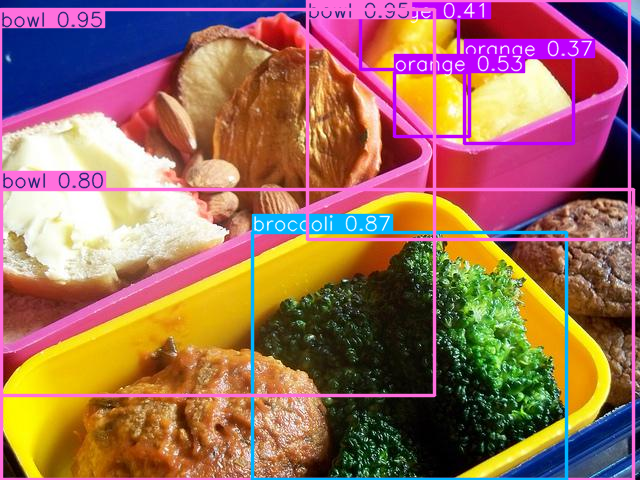

In [ ]:
results=model.predict("/content/dataset/coco128/images/train2017/000000000009.jpg",save=True)
results[0].show()

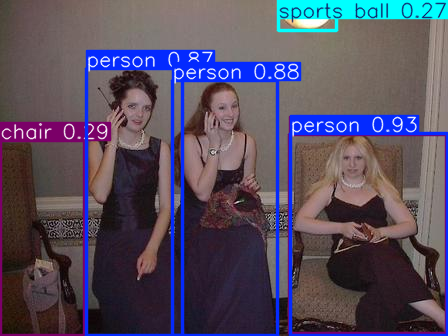

# **Day 5: Build a Simple Streamlit App**
Goal: Deploy YOLO model with a Streamlit UI.
- Upload image or video
- Display detection result


In [ ]:
!pip install streamlit==1.38.0 ultralytics==8.3.0 pyngrok==7.1.6 opencv-python-headless pillow pandas

In [ ]:
%%writefile app_streamlit.py
import streamlit as st
from ultralytics import YOLO
import numpy as np
from PIL import Image
import cv2, tempfile, os, glob
import pandas as pd
from pathlib import Path

st.set_page_config(page_title="Object Detection (DevTown)", layout="wide")
background_url = "https://i.ibb.co/FqVqvBBN/web-back.png"


st.markdown(
    f"""
    <style>
    .stApp {{
        background: url("{background_url}") no-repeat center center fixed;
        background-size: cover;
    }}
    /* Sidebar styling */
    section[data-testid="stSidebar"] {{
        background: rgba(0, 0, 0, 0.3);
        backdrop-filter: blur(10px);
        border-radius: 12px;
        padding: 10px;
    }}
    /* File uploader styling */
    div[data-testid="stFileUploader"] {{
        background: rgba(0, 0, 0, 0.3);
        backdrop-filter: blur(10px);
        border-radius: 12px;
        padding: 15px;
    }}
    /* DataFrame styling */
    .stDataFrame {{
        background: rgba(255, 255, 255, 0.85);
        border-radius: 12px;
        padding: 10px;
        box-shadow: 0 4px 10px rgba(0,0,0,0.3);
    }}
    /* Dark text */
    h1, h2, h3, h4, h5, h6, p, label, span, div {{
        color: #1a1a1a !important;
        font-weight: 500;
    }}
    </style>
    """,
    unsafe_allow_html=True
)

st.title("Object Detection (DevTown)")

uploaded_weights = st.sidebar.file_uploader("Upload custom .pt weights (optional)", type=["pt"])
conf = st.sidebar.slider("Confidence threshold", 0.0, 1.0, 0.25, 0.01)
img_size = st.sidebar.selectbox("Inference image size (px)", [320, 416, 640, 1280], index=2)

@st.cache_resource
def load_model(weights_path="yolov8n.pt"):
    return YOLO(weights_path)

def save_uploaded_file(uploaded_file, suffix=""):
    suffix = suffix if suffix else Path(uploaded_file.name).suffix
    tf = tempfile.NamedTemporaryFile(delete=False, suffix=suffix)
    tf.write(uploaded_file.getbuffer())
    tf.flush()
    return tf.name

def annotate_and_table(results, model):
    res = results[0]
    try:
        plotted = res.plot()
        annotated = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)
    except Exception:
        annotated = res.orig_img if hasattr(res, "orig_img") else None

    detections = []
    try:
        boxes = res.boxes
        if boxes is not None and len(boxes) > 0:
            for c, cf, box in zip(boxes.cls.cpu().numpy(), boxes.conf.cpu().numpy(), boxes.xyxy.cpu().numpy()):
                name = model.names[int(c)]
                detections.append({"class": name, "conf": float(cf), "bbox": [float(x) for x in box]})
    except:
        detections = []

    return annotated, pd.DataFrame(detections)

weights_to_load = "yolov8n.pt"
if uploaded_weights:
    weights_to_load = save_uploaded_file(uploaded_weights, suffix=".pt")
    st.sidebar.success("Using uploaded weights")

model = load_model(weights_to_load)

mode = st.radio("Select input", ["Image upload", "Video upload"])

if mode == "Image upload":
    uploaded = st.file_uploader("Upload image", type=["jpg","jpeg","png"])
    if uploaded:
        img = Image.open(uploaded).convert("RGB")
        st.image(img, caption="Input image")
        results = model.predict(np.array(img), conf=conf, imgsz=img_size)
        annotated, df = annotate_and_table(results, model)
        if annotated is not None:
            st.image(annotated, caption="Annotated")
        if not df.empty:
            st.dataframe(df)

elif mode == "Video upload":
    uploaded_vid = st.file_uploader("Upload video", type=["mp4","mov","avi","mkv"])
    if uploaded_vid:
        tmp = save_uploaded_file(uploaded_vid)
        st.video(tmp)
        project_dir = tempfile.mkdtemp()
        results = model.predict(source=tmp, conf=conf, imgsz=img_size, project=project_dir, name="run", save=True)
        try:
            out_dir = str(results[0].save_dir)
            vids = glob.glob(os.path.join(out_dir, "*"))
            vids = [v for v in vids if Path(v).suffix.lower() in [".mp4",".avi",".mov",".mkv"]]
            if vids:
                st.success("Annotated video")
                st.video(vids[0])
        except:
            st.warning("Could not display annotated video")


Writing app_streamlit.py


In [ ]:
from pyngrok import ngrok


NGROK_AUTH_TOKEN = "************************************" #unique for everyone
ngrok.set_auth_token(NGROK_AUTH_TOKEN)


public_url = ngrok.connect(8501)
print("Public URL:", public_url)


!streamlit run app_streamlit.py --server.port 8501 &

import time
while True:
    time.sleep(60)

Public URL: NgrokTunnel: "https://ab8848889441.ngrok-free.app" -> "http://localhost:8501"



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.34.94.72:8501

WARNING ⚠️ Ultralytics settings reset to default values. This may be due to a possible problem with your settings or a recent ultralytics package update. 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
2025-09-14 14:32:00.032 Examining the path of torch.classes raised: Tried to instantiate class '__path__._path', but it does not exist! Ensure that it is registered via torch::class_

0: 640x384 2 persons, 1 cup, 54.5ms
Speed: 3.7ms preprocess, 54.5ms inference, 78.0ms postprocess per image at shape (1, 3, 640, 384)
2

KeyboardInterrupt: 